# Notebook 06 — PyTorch Built-in Transformer (Library)

**Model**: Standard `nn.TransformerEncoder` from PyTorch  
**Type**: Library-based (vs STFormer which is hand-crafted from scratch)  

## Key Difference vs STFormer (Notebook 04)
| Aspect | STFormer (Scratch) | PyTorch Transformer (Library) |
|--------|--------------------|---------------------------------|
| Closeness + Period | ✅ Two separate branches | ❌ Single branch |
| Spatial attention | ✅ Custom spatial block | ❌ None (temporal only) |
| Fusion module | ✅ Learnable α, β | ❌ None |
| Implementation | Manual from scratch | `nn.TransformerEncoderLayer` |

---

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle

from utils.data_utils  import load_processed, make_loaders, inverse_transform
from utils.metrics     import compute_all_metrics, print_metrics
from utils.train_utils import EarlyStopping, full_train, predict_all, count_parameters

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed('../data/processed')
train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size_train=32, batch_size_eval=64
)
T_IN      = X_train.shape[1]
N_SENSORS = X_train.shape[2]
print(f'T_in={T_IN}, N={N_SENSORS}')

[load] Loaded processed data from ../data/processed\processed_data.pkl
[loaders] Train:23978  Val:3415  Test:6843
T_in=12, N=207


## 1. Model — PyTorch `nn.TransformerEncoder`

Using PyTorch's built-in Transformer components directly — no manual attention code.

In [4]:
class PyTorchTransformerPredictor(nn.Module):
    """
    Traffic prediction using PyTorch's nn.TransformerEncoder.

    Architecture:
        Input  (B, T=12, N=207)
        → Linear: N → d_model (input projection)
        → Sinusoidal positional encoding
        → N × TransformerEncoderLayer (d_model, n_heads, ff_dim)
        → Mean pooling over T dim
        → Linear: d_model → N (output)

    All using nn.TransformerEncoder — the library approach.
    """

    def __init__(self, n_sensors=207, d_model=64, n_heads=4,
                 n_layers=2, ff_dim=256, dropout=0.1, t_in=12):
        super().__init__()

        # Input projection: sensor space → embedding space
        self.input_proj = nn.Linear(n_sensors, d_model)

        # Sinusoidal positional encoding (classic from 'Attention is All You Need')
        self.register_buffer('pos_enc', self._make_pos_enc(t_in, d_model))

        # PyTorch built-in TransformerEncoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,      # Pre-norm (more stable)
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
            norm=nn.LayerNorm(d_model),
        )

        # Output head
        self.output_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_sensors),
        )

    @staticmethod
    def _make_pos_enc(max_len, d_model):
        """Sinusoidal positional encoding from 'Attention is All You Need'."""
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        return pe.unsqueeze(0)   # (1, T, d_model)

    def forward(self, x):
        # x : (B, T, N)
        x = self.input_proj(x)      # (B, T, d_model)
        x = x + self.pos_enc        # add sinusoidal pos encoding

        # nn.TransformerEncoder (batch_first=True)
        x = self.transformer(x)     # (B, T, d_model)

        # Pool over time → single representation
        x = x.mean(dim=1)           # (B, d_model)

        return self.output_head(x)  # (B, N)


model = PyTorchTransformerPredictor(
    n_sensors=N_SENSORS, d_model=64, n_heads=4,
    n_layers=2, ff_dim=256, dropout=0.1, t_in=T_IN
).to(device)

print(f'Parameters: {count_parameters(model):,}')

# Shape check
with torch.no_grad():
    dummy = torch.randn(4, T_IN, N_SENSORS).to(device)
    out = model(dummy)
    print(f'Input: {dummy.shape}  →  Output: {out.shape}  ← should be (4, 207)')

Parameters: 131,023


c:\Users\LOQ 15IRX9\Downloads\DL_Project_2\.venv-2\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Input: torch.Size([4, 12, 207])  →  Output: torch.Size([4, 207])  ← should be (4, 207)


## 2. Training

In [5]:
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
early_stop = EarlyStopping(patience=10, path='../models/transformer_lib_best.pth')

train_losses, val_losses = full_train(
    model, train_loader, val_loader,
    optimizer, criterion, scheduler, early_stop,
    device, max_epochs=100, model_name='PyTorch Transformer (Library)'
)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training PyTorch Transformer (Library) on cuda
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch    1/100 | train=0.047521 | val=0.025991
  ✓ Best model saved → ../models/transformer_lib_best.pth  (val_loss=0.025991)
  ✓ Best model saved → ../models/transformer_lib_best.pth  (val_loss=0.023024)
  ✓ Best model saved → ../models/transformer_lib_best.pth  (val_loss=0.021386)
  ✓ Best model saved → ../models/transformer_lib_best.pth  (val_loss=0.019191)
  Epoch    5/100 | train=0.018812 | val=0.018317
  ✓ Best model saved → ../models/transformer_lib_best.pth  (val_loss=0.018317)
  ✓ Best model saved → ../models/transformer_lib_best.pth  (val_loss=0.018130)
  ✓ Best model saved → ../models/transformer_lib_best.pth  (val_loss=0.017332)
  ✓ Best model saved → ../models/transformer_lib_best.pth  (val_loss=0.017072)
  EarlyStopping counter: 1/10
  Epoch   10/100 | train=0.016475 | val=0.015933
  ✓ Best model saved → ../models/transf

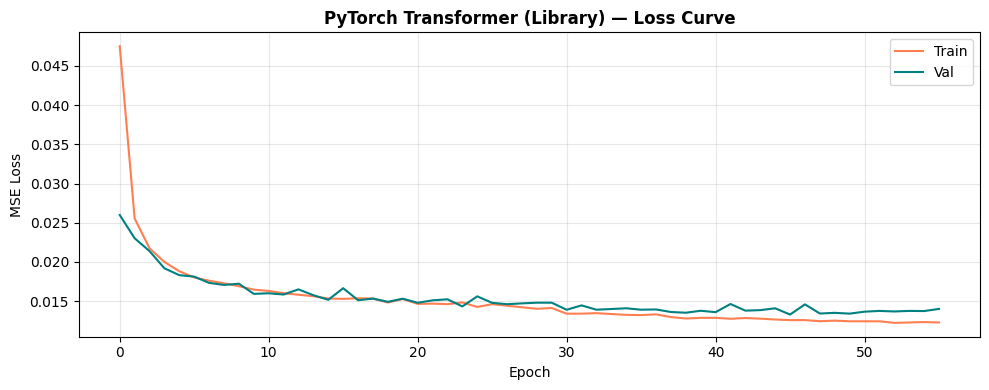

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train', color='coral')
ax.plot(val_losses,   label='Val',   color='teal')
ax.set_title('PyTorch Transformer (Library) — Loss Curve', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/transformer_lib_training_curve.png', dpi=150)
plt.show()

## 3. Evaluation

In [7]:
preds_norm, labels_norm = predict_all(model, test_loader, device)
preds  = inverse_transform(preds_norm, scaler)
labels = inverse_transform(labels_norm, scaler)

metrics = compute_all_metrics(preds, labels)
print_metrics(metrics, 'PyTorch Transformer (Library)')

with open('../results/transformer_lib_metrics.pkl', 'wb') as f:
    pickle.dump({'model': 'PyTorch Transformer (Library)', 'metrics': metrics,
                 'train_losses': train_losses, 'val_losses': val_losses,
                 'params': count_parameters(model)}, f)
print('✅ Metrics saved → results/transformer_lib_metrics.pkl')


  PyTorch Transformer (Library) — Evaluation Metrics
  MAE  : 4.8293 km/h
  RMSE : 9.6216 km/h
  MAPE : 10.34 %
  R²   : 0.8216

✅ Metrics saved → results/transformer_lib_metrics.pkl


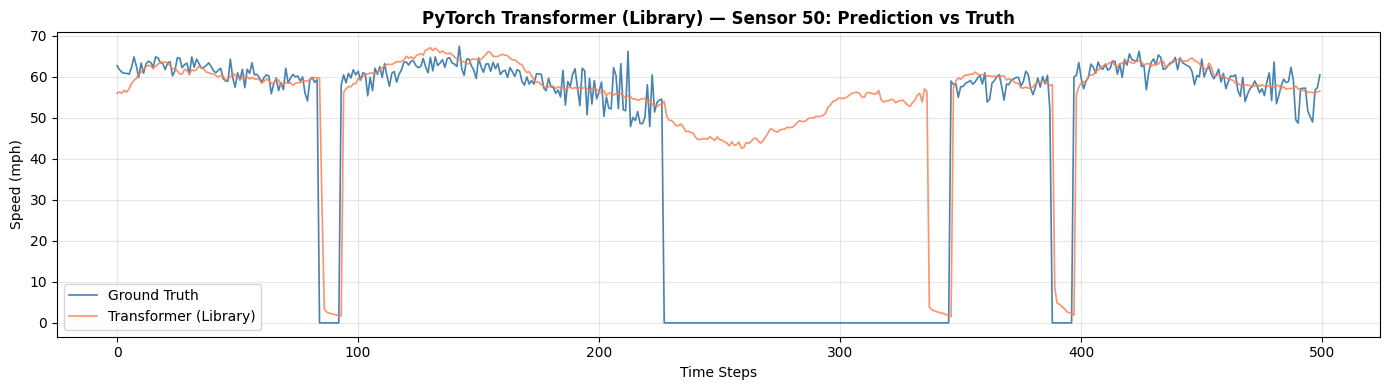

In [8]:
# Prediction plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(labels[:500, 50], label='Ground Truth',             color='steelblue',  lw=1.2)
ax.plot(preds[:500,  50], label='Transformer (Library)',    color='coral',       lw=1.2, alpha=0.85)
ax.set_title('PyTorch Transformer (Library) — Sensor 50: Prediction vs Truth', fontweight='bold')
ax.set_xlabel('Time Steps'); ax.set_ylabel('Speed (mph)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/transformer_lib_prediction_viz.png', dpi=150)
plt.show()